# Supervised Learning
## 2.1 Classical ML Models (Logistic Regression & Gradient Boosted Tree)
We decided to mostly use the last-measured value as input feature as this the closest to death and should be most informative. The 4 static values will be kept (for static weight this is the first).

In [9]:
# Simple Feature Prepro
# For each patient: last-measured value of each dynamic variable + static variables

import numpy as np
import pandas as pd
import pickle

# ── Load processed (scaled, imputed) data ────────────────────────────────────
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight']
ALL_FEATURES = DYNAMIC_VARS + STATIC_VARS  # 41 features total

def extract_simple_features(df):
    """
    Per patient:
      - Dynamic variables: take the last-measured value (hour 48 row after ffill)
      - Static variables: take as-is (constant across hours)
    Returns one row per patient with features + label.
    """
    last_row = df.sort_values(["RecordID", "hour"]).groupby("RecordID").last().reset_index()
    
    features = last_row[["RecordID"] + ALL_FEATURES].copy()
    labels   = last_row[["RecordID", "In-hospital_death"]].copy()
    
    return features, labels

X_train, y_train = extract_simple_features(df_train)
X_val,   y_val   = extract_simple_features(df_val)
X_test,  y_test  = extract_simple_features(df_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"\nTrain mortality rate: {y_train['In-hospital_death'].mean():.3f}")
print(f"Val   mortality rate: {y_val['In-hospital_death'].mean():.3f}")
print(f"Test  mortality rate: {y_test['In-hospital_death'].mean():.3f}")
print(f"\nNaN in X_train: {X_train[ALL_FEATURES].isna().sum().sum()}")
X_train.head()

Train: (4000, 42), Val: (4000, 42), Test: (4000, 42)
Features (41): ['ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH', 'Age', 'Gender', 'Height', 'StaticWeight']

Train mortality rate: 0.139
Val   mortality rate: 0.142
Test  mortality rate: 0.146

NaN in X_train: 0


,RecordID,ALP,ALT,AST,Albumin,BUN,Bilirubin,Cholesterol,Creatinine,DiasABP,...,TroponinI,TroponinT,Urine,WBC,Weight,pH,Age,Gender,Height,StaticWeight
0,132539,0.666667,0.222222,-0.695652,-0.218305,-0.6875,-0.333333,-0.374775,-0.333333,0.279561,...,-0.318182,-0.185185,1.818182,-0.471044,-0.302991,0.210159,-0.583612,0.0,-0.451583,-2.437098
1,132540,-0.518519,-0.055556,0.217391,-0.446695,0.1250,0.666667,-0.361386,0.666667,-0.704886,...,0.409091,1.259259,1.272727,0.128322,-0.019384,-0.351185,0.669324,1.0,0.353422,0.139491
2,132541,1.074074,2.555556,5.217391,-1.588648,-1.0000,7.000000,1.687192,-1.000000,0.853822,...,0.318182,-0.296296,-0.409091,-0.962831,-1.089358,1.519962,-1.153129,0.0,-0.451583,-0.637229
3,132543,1.074074,-0.944444,-1.260870,3.207554,-0.5625,-1.666667,-0.160545,-0.333333,0.033449,...,-0.113636,-0.074074,4.272727,-0.701569,0.109529,-0.164070,0.213711,1.0,0.670353,0.233071
4,132545,0.037037,-0.166667,-0.130435,0.695258,0.3750,-0.666667,0.107243,0.166667,-0.294700,...,-0.250000,-0.074074,0.000000,-1.177988,-0.822938,0.023044,1.352744,0.0,-0.939658,-2.437098


In [10]:
# ── Logistic Regression ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve, precision_recall_curve)

# Prepare arrays (drop RecordID)
X_tr = X_train[ALL_FEATURES].values
X_v  = X_val[ALL_FEATURES].values
X_te = X_test[ALL_FEATURES].values
y_tr = y_train["In-hospital_death"].values
y_v  = y_val["In-hospital_death"].values
y_te = y_test["In-hospital_death"].values

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_tr, y_tr)

lr_proba_val  = lr.predict_proba(X_v)[:, 1]
lr_proba_test = lr.predict_proba(X_te)[:, 1]

print("=== Logistic Regression (default) ===")
print(f"Val  AUROC: {roc_auc_score(y_v, lr_proba_val):.4f}  |  AUPRC: {average_precision_score(y_v, lr_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, lr_proba_test):.4f}  |  AUPRC: {average_precision_score(y_te, lr_proba_test):.4f}")

=== Logistic Regression (default) ===
Val  AUROC: 0.8482  |  AUPRC: 0.5183
Test AUROC: 0.8417  |  AUPRC: 0.4914


In [11]:
# ── Gradient Boosted Tree ────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
)
gbt.fit(X_tr, y_tr)

gbt_proba_val  = gbt.predict_proba(X_v)[:, 1]
gbt_proba_test = gbt.predict_proba(X_te)[:, 1]

print("=== Gradient Boosted Tree ===")
print(f"Val  AUROC: {roc_auc_score(y_v, gbt_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, gbt_proba_test):.4f}")
print(f"\nVal classification report (threshold=0.5):")
print(classification_report(y_v, (gbt_proba_val >= 0.5).astype(int), target_names=["Survived", "Died"]))

=== Gradient Boosted Tree ===
Val  AUROC: 0.8474
Test AUROC: 0.8443

Val classification report (threshold=0.5):
              precision    recall  f1-score   support

    Survived       0.90      0.96      0.93      3432
        Died       0.58      0.33      0.42       568

    accuracy                           0.87      4000
   macro avg       0.74      0.65      0.68      4000
weighted avg       0.85      0.87      0.86      4000



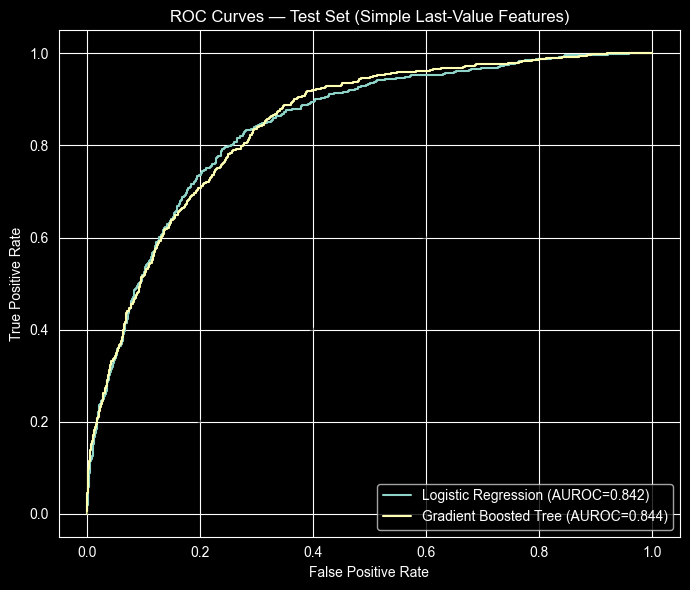

In [12]:
# ── Compare models ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

for name, proba in [("Logistic Regression", lr_proba_test), ("Gradient Boosted Tree", gbt_proba_test)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set (Simple Last-Value Features)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Hyperparameter Tuning with GridSearchCV
We use 5-fold stratified cross-validation on the training set, optimizing for AUROC.

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression Grid Search ─────────────────────────────────────────
# Use l1_ratio instead of deprecated penalty parameter:
#   l1_ratio=1 → L1 (Lasso), l1_ratio=0 → L2 (Ridge), 0<l1_ratio<1 → ElasticNet
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
    "class_weight": ["balanced", None],
}

lr_gs = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
lr_gs.fit(X_tr, y_tr)

print(f"\n=== Logistic Regression — Best Params ===")
print(lr_gs.best_params_)
print(f"Best CV AUROC: {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [14]:
# ── Gradient Boosted Tree Grid Search ────────────────────────────────────────
gbt_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.6, 0.7],
    "min_samples_leaf": [15, 20, 25],
}

gbt_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gbt_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
gbt_gs.fit(X_tr, y_tr)

print(f"\n=== Gradient Boosted Tree — Best Params ===")
print(gbt_gs.best_params_)
print(f"Best CV AUROC: {gbt_gs.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


KeyboardInterrupt: 

In [15]:
# ── Evaluate tuned models on val & test ──────────────────────────────────────
from sklearn.metrics import average_precision_score, precision_recall_curve

lr_best  = lr_gs.best_estimator_
gbt_best = gbt_gs.best_estimator_

results = {}
print(f"{'Model':15s}  {'Val AUROC':>10s}  {'Val AUPRC':>10s}  {'Test AUROC':>11s}  {'Test AUPRC':>11s}")
print("-" * 65)
for name, model in [("LR (tuned)", lr_best), ("GBT (tuned)", gbt_best)]:
    p_val  = model.predict_proba(X_v)[:, 1]
    p_test = model.predict_proba(X_te)[:, 1]
    auc_val  = roc_auc_score(y_v, p_val)
    auc_test = roc_auc_score(y_te, p_test)
    prc_val  = average_precision_score(y_v, p_val)
    prc_test = average_precision_score(y_te, p_test)
    results[name] = {"val_auc": auc_val, "test_auc": auc_test,
                     "val_prc": prc_val, "test_prc": prc_test, "proba_test": p_test}
    print(f"{name:15s}  {auc_val:10.4f}  {prc_val:10.4f}  {auc_test:11.4f}  {prc_test:11.4f}")

# ── ROC & PRC comparison: default vs tuned ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curves = [
    ("LR (default)",  lr_proba_test),
    ("LR (tuned)",    results["LR (tuned)"]["proba_test"]),
    ("GBT (default)", gbt_proba_test),
    ("GBT (tuned)",   results["GBT (tuned)"]["proba_test"]),
]

# ROC
for name, proba in curves:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Test Set)")
axes[0].legend(fontsize=9)

# PRC
baseline_prc = y_te.mean()
for name, proba in curves:
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    axes[1].plot(rec, prec, label=f"{name} ({ap:.3f})")
axes[1].axhline(baseline_prc, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline_prc:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Test Set)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

## 2.3 Feature Engineering

The simple last-value features only use the final hour of each variable, discarding 47 hours of temporal information. We engineer additional features to capture:

- **Last value**: the most recent measurement (already used above)
- **First value**: admission baseline
- **First–last delta**: trajectory over the full 48h stay
- **Min / Max**: worst values during the stay
- **Mean / Std**: average level and variability (instability signals)
- **Missingness count**: number of hours with an actual measurement (sicker patients get tested more often)

In [22]:
# ── Engineered Feature Extraction ────────────────────────────────────────────
# Use scaled/imputed data for all features EXCEPT std, which is computed on raw (pre-imputation) data to reflect true variability.

# Raw hourly grids (before imputation & scaling) for std calculation
df_train_raw = pd.read_parquet("processed/set_a.parquet")
df_val_raw   = pd.read_parquet("processed/set_b.parquet")
df_test_raw  = pd.read_parquet("processed/set_c.parquet")

def extract_engineered_features(df_scaled, df_raw):

    grp = df_scaled.groupby("RecordID")
    grp_raw = df_raw.groupby("RecordID")
    
    last  = grp[DYNAMIC_VARS].last()
    first = grp[DYNAMIC_VARS].first()
    mean  = grp[DYNAMIC_VARS].mean()
    vmin  = grp[DYNAMIC_VARS].min()
    vmax  = grp[DYNAMIC_VARS].max()
    delta = last - first
    std = grp_raw[DYNAMIC_VARS].std().fillna(0)
    
#New column names
    last  = last.rename(columns={c: f"{c}_last" for c in DYNAMIC_VARS})
    first = first.rename(columns={c: f"{c}_first" for c in DYNAMIC_VARS})
    mean  = mean.rename(columns={c: f"{c}_mean" for c in DYNAMIC_VARS})
    std   = std.rename(columns={c: f"{c}_std" for c in DYNAMIC_VARS})
    vmin  = vmin.rename(columns={c: f"{c}_min" for c in DYNAMIC_VARS})
    vmax  = vmax.rename(columns={c: f"{c}_max" for c in DYNAMIC_VARS})
    delta = delta.rename(columns={c: f"{c}_delta" for c in DYNAMIC_VARS})
    
    statics = grp[STATIC_VARS].first()
    labels  = grp["In-hospital_death"].first().reset_index()
    
    features = pd.concat([last, first, mean, std, vmin, vmax, delta, statics], axis=1)
    features = features.reset_index()
    
    return features, labels

X_train_eng, y_train_eng = extract_engineered_features(df_train, df_train_raw)
X_val_eng,   y_val_eng   = extract_engineered_features(df_val,   df_val_raw)
X_test_eng,  y_test_eng  = extract_engineered_features(df_test,  df_test_raw)

ENG_FEATURES = [c for c in X_train_eng.columns if c != "RecordID"]

print(f"Engineered feature count: {len(ENG_FEATURES)}")
print(f"  = 37 dynamic × 7 aggregations + {len(STATIC_VARS)} static = {37*7 + len(STATIC_VARS)}")
print(f"Train: {X_train_eng.shape}, Val: {X_val_eng.shape}, Test: {X_test_eng.shape}")
print(f"\nStd source: raw (pre-imputation) data")
print(f"All other features: scaled/imputed data")
print(f"\nNaN count: {X_train_eng[ENG_FEATURES].isna().sum().sum()}")
X_train_eng.head()

Engineered feature count: 263
  = 37 dynamic × 7 aggregations + 4 static = 263
Train: (4000, 264), Val: (4000, 264), Test: (4000, 264)

Std source: raw (pre-imputation) data
All other features: scaled/imputed data

NaN count: 0


,RecordID,ALP_last,ALT_last,AST_last,Albumin_last,BUN_last,Bilirubin_last,Cholesterol_last,Creatinine_last,DiasABP_last,...,TroponinI_delta,TroponinT_delta,Urine_delta,WBC_delta,Weight_delta,pH_delta,Age,Gender,Height,StaticWeight
0,132539,0.666667,0.222222,-0.695652,-0.218305,-0.6875,-0.333333,-0.374775,-0.333333,0.279561,...,0.0,0.0,1.818182,-0.245894,0.000000,0.000000,-0.583612,0.0,-0.451583,-2.437098
1,132540,-0.518519,-0.055556,0.217391,-0.446695,0.1250,0.666667,-0.361386,0.666667,-0.704886,...,0.0,0.0,1.454545,0.215157,0.240637,-0.561344,0.669324,1.0,0.353422,0.139491
2,132541,1.074074,2.555556,5.217391,-1.588648,-1.0000,7.000000,1.687192,-1.000000,0.853822,...,0.0,0.0,-0.590909,-0.737681,0.000000,1.871147,-1.153129,0.0,-0.451583,-0.637229
3,132543,1.074074,-0.944444,-1.260870,3.207554,-0.5625,-1.666667,-0.160545,-0.333333,0.033449,...,0.0,0.0,4.181818,-0.353472,0.000000,0.000000,0.213711,1.0,0.670353,0.233071
4,132545,0.037037,-0.166667,-0.130435,0.695258,0.3750,-0.666667,0.107243,0.166667,-0.294700,...,0.0,0.0,0.181818,-1.121890,0.000000,0.000000,1.352744,0.0,-0.939658,-2.437098


In [23]:
# ── Scale engineered features (fit on train only) ────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_eng = StandardScaler()
X_tr_eng = scaler_eng.fit_transform(X_train_eng[ENG_FEATURES])
X_v_eng  = scaler_eng.transform(X_val_eng[ENG_FEATURES])
X_te_eng = scaler_eng.transform(X_test_eng[ENG_FEATURES])

y_tr_eng = y_train_eng["In-hospital_death"].values
y_v_eng  = y_val_eng["In-hospital_death"].values
y_te_eng = y_test_eng["In-hospital_death"].values

print(f"Scaled feature matrices — Train: {X_tr_eng.shape}, Val: {X_v_eng.shape}, Test: {X_te_eng.shape}")

Scaled feature matrices — Train: (4000, 263), Val: (4000, 263), Test: (4000, 263)


In [ ]:
# ── Train LR & GBT on engineered features with GridSearchCV ──────────────────

# LR
lr_gs_eng = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid={
        "C": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
        "class_weight": ["balanced", None],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lr_gs_eng.fit(X_tr_eng, y_tr_eng)
print(f"\nLR best params: {lr_gs_eng.best_params_}")
print(f"LR best CV AUROC: {lr_gs_eng.best_score_:.4f}")

# GBT
gbt_gs_eng = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8],
        "min_samples_leaf": [10, 20],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
gbt_gs_eng.fit(X_tr_eng, y_tr_eng)
print(f"\nGBT best params: {gbt_gs_eng.best_params_}")
print(f"GBT best CV AUROC: {gbt_gs_eng.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [ ]:
# ── Compare: simple features vs engineered features ──────────────────────────
lr_eng  = lr_gs_eng.best_estimator_
gbt_eng = gbt_gs_eng.best_estimator_

print(f"{'Model':<30s} {'Val AUROC':>10s} {'Val AUPRC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 75)

all_curves = []
for name, model, Xv, Xte, yv, yte in [
    ("LR  (simple, tuned)",  lr_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("LR  (engineered)",     lr_eng,                  X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("GBT (simple, tuned)",  gbt_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("GBT (engineered)",     gbt_eng,                 X_v_eng, X_te_eng, y_v_eng, y_te_eng),
]:
    pv  = model.predict_proba(Xv)[:, 1]
    pt  = model.predict_proba(Xte)[:, 1]
    auc_v = roc_auc_score(yv, pv)
    auc_t = roc_auc_score(yte, pt)
    prc_v = average_precision_score(yv, pv)
    prc_t = average_precision_score(yte, pt)
    print(f"{name:<30s} {auc_v:10.4f} {prc_v:10.4f} {auc_t:11.4f} {prc_t:11.4f}")
    all_curves.append((name, pt, yte))

# ── ROC & PRC plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, pt, yte in all_curves:
    fpr, tpr, _ = roc_curve(yte, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yte, pt):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — Simple vs Engineered Features (Test)")
axes[0].legend(fontsize=8)

baseline = y_te_eng.mean()
for name, pt, yte in all_curves:
    prec, rec, _ = precision_recall_curve(yte, pt)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yte, pt):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PRC — Simple vs Engineered Features (Test)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Feature Selection via ElasticNet

The tuned LR with L1/ElasticNet regularization shrinks unimportant coefficients to zero. We extract the non-zero features and retrain both LR and GBT on only those — reducing noise and potentially improving generalization.

In [ ]:
# ── Extract non-zero features from ElasticNet LR ─────────────────────────────
lr_coefs = lr_eng.coef_[0]
nonzero_mask = lr_coefs != 0
selected_features = [f for f, m in zip(ENG_FEATURES, nonzero_mask) if m]

print(f"ElasticNet LR selected {len(selected_features)} / {len(ENG_FEATURES)} features")
print(f"Dropped {len(ENG_FEATURES) - len(selected_features)} features (coef = 0)\n")

# Show top features by absolute coefficient
coef_series = pd.Series(lr_coefs, index=ENG_FEATURES)
top_features = coef_series[nonzero_mask].abs().sort_values(ascending=False).head(20)
print("Top 20 features by |coefficient|:")
for feat, val in top_features.items():
    sign = "+" if coef_series[feat] > 0 else "-"
    print(f"  {sign} {feat:<30s}  |coef| = {val:.4f}")

In [ ]:
# ── Retrain LR & GBT on selected features only ──────────────────────────────
sel_idx = [ENG_FEATURES.index(f) for f in selected_features]

X_tr_sel = X_tr_eng[:, sel_idx]
X_v_sel  = X_v_eng[:, sel_idx]
X_te_sel = X_te_eng[:, sel_idx]

# LR on selected features
lr_gs_sel = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid={
        "C": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
        "class_weight": ["balanced", None],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lr_gs_sel.fit(X_tr_sel, y_tr_eng)

# GBT on selected features
gbt_gs_sel = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8],
        "min_samples_leaf": [10, 20],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
gbt_gs_sel.fit(X_tr_sel, y_tr_eng)

print(f"\nLR  (selected) best CV AUROC: {lr_gs_sel.best_score_:.4f}  params: {lr_gs_sel.best_params_}")
print(f"GBT (selected) best CV AUROC: {gbt_gs_sel.best_score_:.4f}  params: {gbt_gs_sel.best_params_}")

In [ ]:
# ── Final comparison: all approaches ─────────────────────────────────────────
lr_sel  = lr_gs_sel.best_estimator_
gbt_sel = gbt_gs_sel.best_estimator_

print(f"{'Model':<35s} {'Val AUROC':>10s} {'Val AUPRC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 80)

final_curves = []
for name, model, Xv, Xte, yv, yte in [
    ("LR  (simple, 41 feat)",        lr_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("LR  (engineered, all feat)",    lr_eng,                  X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("LR  (engineered, selected)",    lr_sel,                  X_v_sel, X_te_sel, y_v_eng, y_te_eng),
    ("GBT (simple, 41 feat)",        gbt_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("GBT (engineered, all feat)",   gbt_eng,                 X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("GBT (engineered, selected)",   gbt_sel,                 X_v_sel, X_te_sel, y_v_eng, y_te_eng),
]:
    pv  = model.predict_proba(Xv)[:, 1]
    pt  = model.predict_proba(Xte)[:, 1]
    auc_v = roc_auc_score(yv, pv)
    auc_t = roc_auc_score(yte, pt)
    prc_v = average_precision_score(yv, pv)
    prc_t = average_precision_score(yte, pt)
    print(f"{name:<35s} {auc_v:10.4f} {prc_v:10.4f} {auc_t:11.4f} {prc_t:11.4f}")
    final_curves.append((name, pt, yte))

# ── ROC & PRC plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, pt, yte in final_curves:
    fpr, tpr, _ = roc_curve(yte, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yte, pt):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — All Approaches (Test)")
axes[0].legend(fontsize=7, loc="lower right")

baseline = y_te_eng.mean()
for name, pt, yte in final_curves:
    prec, rec, _ = precision_recall_curve(yte, pt)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yte, pt):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PRC — All Approaches (Test)")
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()